In [1]:
import numpy as np
from votekit.cvr_loaders import load_scottish
import matplotlib.pyplot as plt
from votekit import PreferenceProfile, PreferenceInterval
from votekit import Ballot
import votekit.ballot_generator as bg
from votekit.elections import STV, fractional_transfer
from votekit.plots import plot_summary_stats
import math
from fractions import Fraction
import itertools as it
import pickle, csv

# used to import local files
import sys  
sys.path.insert(1, './')


from collections import Counter
from scipy.stats import wasserstein_distance, kstest
import pandas as pd


SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
b_bloc_parties = ['Scottish National Party (SNP)', 'Green (Gr)']
file_names = {("fife", 2022, 21): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/fife_2022_ward21.csv",
              ("aberdeen", 2017, 12) : "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/aberdeen_2017_ward12.csv",
              ("aberdeen", 2022, 12): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/aberdeen_2022_ward12.csv",
              ("angus", 2012, 8): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/angus_2012_ward8.csv",
              ("falkirk", 2017, 6): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/falkirk_2017_ward6.csv",
              ("clackmannanshire", 2012, 2): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/clackmannanshire_2012_ward2.csv",
              ("renfrewshire", 2017, 1): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/renfrewshire_2017_ward1.csv",
              ("glasgow", 2012, 16): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/glasgow_2012_ward16.csv",
              ("north-ayrshire", 2022, 1): "/cluster/tufts/mggg/cdonna01/EC_paper/scottish/election_data/north_ayrshire_2022_north_coast.csv"
              }


new_models = ["CS-C", "CS-W", "s-BT", "s-PL"]
old_models = ["SB", "IC", "IAC"]

scottish_color = ["#1560BD"]
model_to_color = {'CS-C': '#D2691E', 'CS-W': '#E32636', 's-BT': '#FFBF00', 's-PL': '#8DB600',"SB":"#09FCEE", "IC":"#1A7601",
                      "IAC":"#929292" }

In [3]:
def bubble_plot_integer(ax, data, labels, colors, title, bloc_order, marker =".", size = 1000):
    # create figure
    # fig, ax = plt.subplots() #plt.figure()
    
    x_max = int(max(max(vector) for vector in data))
    bin_min = 0
    bin_max = x_max
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    
    for j, vector in enumerate(data):
        x = [i for i in range(x_max+1)] # x=0,...,x_max
        y = [j+1]*len(x) # put each vector at a different height
        
        bin_heights, bin_edges = np.histogram(vector, bins = bins,density=True)
        circle_areas = [size*bin_heights[i] for i in range(x_max+1)]
        ax.scatter(x, y, s=circle_areas, alpha=1, color = colors[j], label = None, edgecolors='black', marker=marker)

    # Add labels and title
    ax.set_xlabel(f'Distance to solid ballot ({bloc_order})')
    ax.set_xticks([i for i in range(x_max+1)])
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_yticks([i+1 for i in range(len(data))], labels)
    ax.set_xlim((-2, x_max+2))
    ax.set_ylim((0.5, len(data)+.5))
    ax.set_title(title)
    
    return ax

In [4]:
import numpy as np
from votekit import Ballot, PreferenceProfile

def bloc_ballot_to_rank_encoding(bloc_type_ballot):
    """ 
    Given a bloc type ballot, convert to rank encoding. eg A>B>A becomes (3 1 | 2)

    Arguments:
        bloc_type_ballot (list[str]): list of strings represent bloc type ballot. eg ["AA", "B"]
            (with all remaining candidates tied at bottom)

    Returns:
        dict[str, list]: (bloc, rank_vector) dictionary
    """
    mult_blocs = [b for s in bloc_type_ballot for b in s]
    num_cands = len(mult_blocs)
    blocs = set(mult_blocs)
    rank_vector = list(range(num_cands, 0, -1))

    bloc_rankings = {b:[] for b in blocs}
    i = 0
    for  s in bloc_type_ballot:
        rank_points = sum(rank_vector[i:i+len(s)])/len(s)
        i += len(s)
        for b in s:
            bloc_rankings[b].append(rank_points)
            
    return bloc_rankings

def bloc_type_to_avg_rank(bloc_type_ballot):
    """
    Given a bloc type ballot, convert to avg rank encoding. eg A>B>A becomes (2 2 | 2)

    Arguments:
        bloc_type_ballot (list[str]): list of strings represent bloc type ballot. eg ["AA", "B"]
            (with all remaining candidates tied at bottom)

    Returns:
        dict[str, list]: (bloc, avg_rank_vector) dictionary
    """
    bloc_rankings = bloc_ballot_to_rank_encoding(bloc_type_ballot)
    return {b: [np.average(vector)]*len(vector) for b, vector in bloc_rankings.items()}

def dist_to_solid_bloc_ballot(bloc_type_ballot, bloc_order):
    """
    Given a bloc type ballot (with all remaining candidates tied at bottom), measure
    swap distance to solid bloc ballot via rank L_1 method. Rounds distance to 4 decimals.

    Arguments:
        bloc_type_ballot (list[str]): list of strings represent bloc type ballot. eg ["AA", "B"].
            (with all remaining candidates tied at bottom)
        bloc_order (str): the order of blocs to consider solid. eg "AB"

    Return:
        float: distance to solid bloc ballot. Rounds distance to 4 decimals.
    """
    bloc_counts = {b:len([bloc for s in bloc_type_ballot for bloc in s if bloc == b])
                                                 for b in bloc_order}

    # first convert bloc_type_ballot to averaged rank encoding
    avg_rank_ballot = bloc_type_to_avg_rank(bloc_type_ballot)

    # then compute the solid bloc ballot
    solid_bloc_ballot = "".join([b*bloc_counts[b] for b in bloc_order])
    
    # convert it to averaged rank encoding
    avg_rank_solid = bloc_type_to_avg_rank(solid_bloc_ballot)

    # compute L_1 distance between the two
    l_1 =  sum(sum(abs(x-y) for x,y in zip(avg_rank_ballot[b], avg_rank_solid[b])) for b in bloc_order)

    return round(l_1/2, 4)

def name_ballot_to_bloc_type(ballot: Ballot, cand_to_bloc: dict):
    """
    Convert a single name Ballot object into a bloc type ballot.

    Arguments:
        ballot (votekit.Ballot)
        cand_to_bloc (dict): a dictionary with keys = candidates and values = bloc assignment.
        
    Returns:
        list[str]: a list where each entry is a str denoting the bloc types (with multiplicity)
            at position i. The strings are alphabetized to ensure "AAB" is the same as "ABA".
    
    """
    candidates = list(cand_to_bloc.keys())
    if len(candidates) != len(set(candidates)):
        raise ValueError("Candidate names must be unique.")
    ballot_type = [-1] * len(ballot.ranking)

    for j, s in enumerate(ballot.ranking):
        bloc_str = ""
        for c in s:
            bloc_str += cand_to_bloc[c]
            # candidate names are unique so this always finds the correct one
            try:
                candidates.remove(c)
            except:
                raise ValueError(f"Candidate {c} appeared on ballot multiple times.")
        
        # sort is necessary to ensure that AB is the same as BA
        ballot_type[j] = "".join(sorted(bloc_str))
    
    # put all candidates remaining tied at bottom
    if len(candidates) > 0:
        tied_bloc_str = "".join([cand_to_bloc[c] for c in candidates])
        ballot_type.append("".join(sorted(tied_bloc_str)))
    
    return ballot_type

def profile_to_bloc_ballot_type(profile: PreferenceProfile, cand_to_bloc: dict):
    """
    Convert profile with name ballots to bloc ballots.

    Arguments:
        profile (votekit.PreferenceProfile)
        cand_to_bloc (dict): a dictionary with keys = candidates and values = bloc assignment.
        
    Returns:
        dict: a dict where each key is a ballot type and each value is the weight of that type.
            A ballot type will be a tuple of Counter objects, which describe the number of candidates and blocs
            tied in that position.
    
    """
    ballot_types = {}

    for ballot in profile.ballots:
        # must be hashable for dictionary
        ballot_type = tuple(name_ballot_to_bloc_type(ballot, cand_to_bloc))
        
        if ballot_type in ballot_types:
            ballot_types[ballot_type] += ballot.weight
        else:
            ballot_types[ballot_type] = ballot.weight
        
        
    return(ballot_types)

def dist_profile_to_solid(profile, cand_to_bloc, bloc_order):
    """
    Compute the distance of each ballot in profile to solid bloc ballot under swap distance.
    Assumes each ballot has integer weight.

    Arguments:
        profile (votekit.PreferenceProfile): each ballot must have integer weight
        cand_to_bloc (dict[str, str]): candidate name to bloc dictionary
        bloc_order (str): order of blocs to consider solid. eg "AB"
    """
    # returns a dictionary type:count
    ballot_types = profile_to_bloc_ballot_type(profile, cand_to_bloc)

    if any(ballot.weight != int(ballot.weight) for ballot in profile.ballots):
        raise ValueError("All ballots must have integer weight")
    
    data = [-1]*int(profile.total_ballot_wt)
    k=0
    for ballot_type, weight in ballot_types.items():
        weight = int(weight)
        dist = dist_to_solid_bloc_ballot(ballot_type, bloc_order)
        data[k:k+weight] = [dist]*weight
        k += weight

    return data
    


# l1 trick does not hold for arbitrary ballots
# def swap_dist(bloc_type_ballot_1, bloc_type_ballot_2, blocs):
#     """
#     Given two bloc type ballot (with all remaining candidates tied at bottom), measure
#     swap distance via rank L_1 method. Rounds distance to 4 decimals.

#     Arguments:
#         bloc_type_ballot_1 (list[str]): list of strings represent bloc type ballot. eg ["AA", "B"].
#             (with all remaining candidates tied at bottom)
#         bloc_type_ballot_2 (list[str]): list of strings represent bloc type ballot. eg ["AA", "B"].
#             (with all remaining candidates tied at bottom)
#         blocs (list[str]): list of bloc names

#     Return:
#         float: distance to solid bloc ballot. Rounds distance to 4 decimals.
#     """

#     # first convert bloc_type_ballot to averaged rank encoding
#     avg_rank_ballot_1 = bloc_type_to_avg_rank(bloc_type_ballot_1)
#     avg_rank_ballot_2 = bloc_type_to_avg_rank(bloc_type_ballot_2)

#     print(avg_rank_ballot_1,avg_rank_ballot_2)

#     # compute L_1 distance between the two
#     l_1 =  sum(sum(abs(x-y) for x,y in zip(avg_rank_ballot_1[b], avg_rank_ballot_2[b])) for b in blocs)

#     return round(l_1/2, 4)



def diss_to_solid(slate_ballot, slate_to_cand_num, bloc_order):
    """
    Compute the dissimilarity between a ballot and solid.
    For incomplete ballots, this is the minimum swap distance between the completion point cloud
    of the ballot and solid. Does NOT handle ballots with arbitrary ties.
    Slate ballot can be entered with or without the missing slates at the end as a tie.


    Args:
        slate_ballot (list[str]): ["A", "A", "B"]
        slate_to_cand_num (dict[str, int]): {"A":3, "B":2}
        bloc_order (str): the order of blocs to consider solid. eg "AB"

    """
    for i,s in enumerate(slate_ballot):
        if len(s) > 1 and i != len(slate_ballot)-1:
            raise TypeError("Ballot has arbitrary tie")

    # handles ignoring arbitrary ties at the end
    sigma = [s for s in slate_ballot if len(s) == 1]
    sigma_record = sigma.copy()
    sigma_completion = sigma.copy()

    solid_bloc_ballot = [bloc_order[0] for _ in range(slate_to_cand_num[bloc_order[0]])]+[bloc_order[1] for _ in range(slate_to_cand_num[bloc_order[1]])]


    for candidate in solid_bloc_ballot:
        if candidate not in sigma_record:
            sigma_completion.append(candidate)
        else:
            sigma_record.remove(candidate)

    return dist_to_solid_bloc_ballot(sigma_completion, bloc_order)


def diss_profile_to_solid(profile, cand_to_bloc, slate_to_cand_num, bloc_order):
    """
    Compute the dissimilarity of each ballot in profile to solid bloc ballot.
    Assumes each ballot has integer weight.

    Arguments:
        profile (votekit.PreferenceProfile): each ballot must have integer weight
        cand_to_bloc (dict[str, str]): candidate name to bloc dictionary
        bloc_order (str): order of blocs to consider solid. eg "AB"
    """
    # returns a dictionary type:count
    ballot_types = profile_to_bloc_ballot_type(profile, cand_to_bloc)

    if any(ballot.weight != int(ballot.weight) for ballot in profile.ballots):
        raise ValueError("All ballots must have integer weight")
    
    data = [-1]*int(profile.total_ballot_wt)
    k=0
    for ballot_type, weight in ballot_types.items():
        weight = int(weight)
        diss = diss_to_solid(list(ballot_type), slate_to_cand_num, bloc_order)
        data[k:k+weight] = [diss]*weight
        k += weight

    return data

# 1 bloc bubble plots dist


('fife', 2022, 21)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


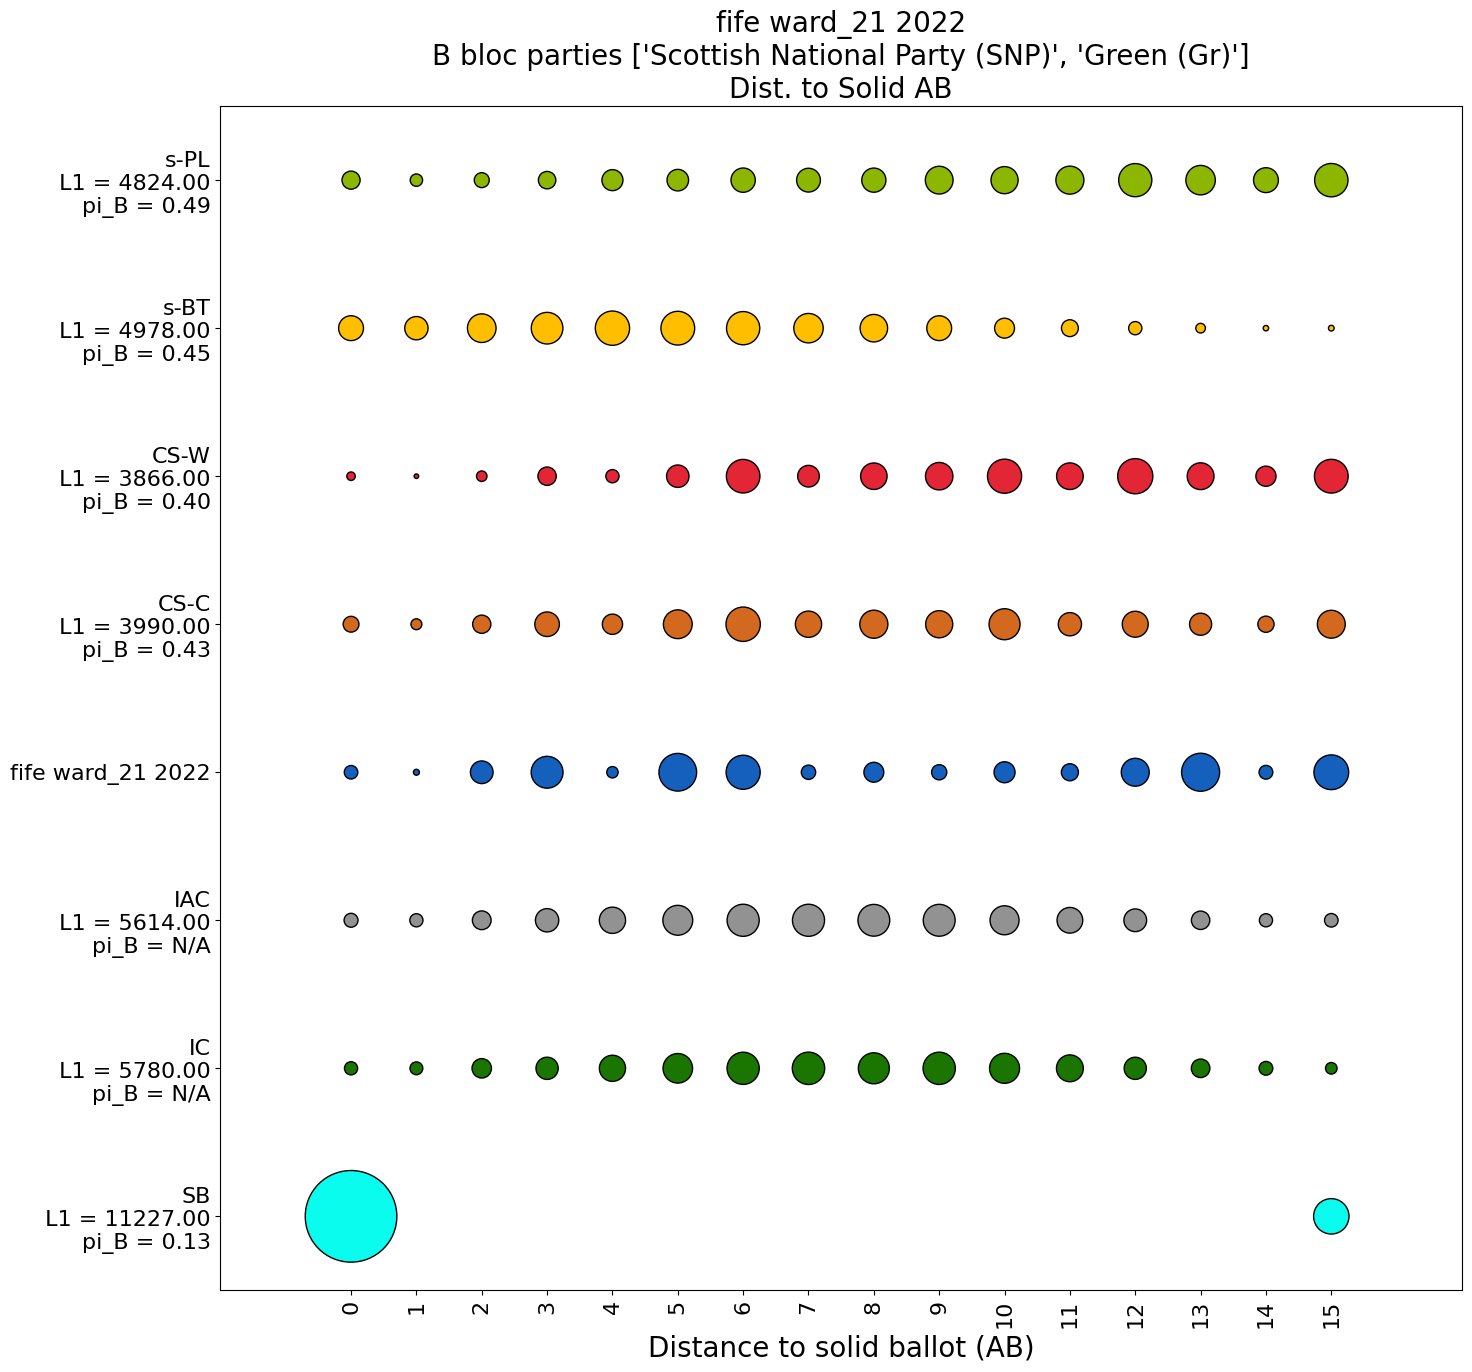

('aberdeen', 2017, 12)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

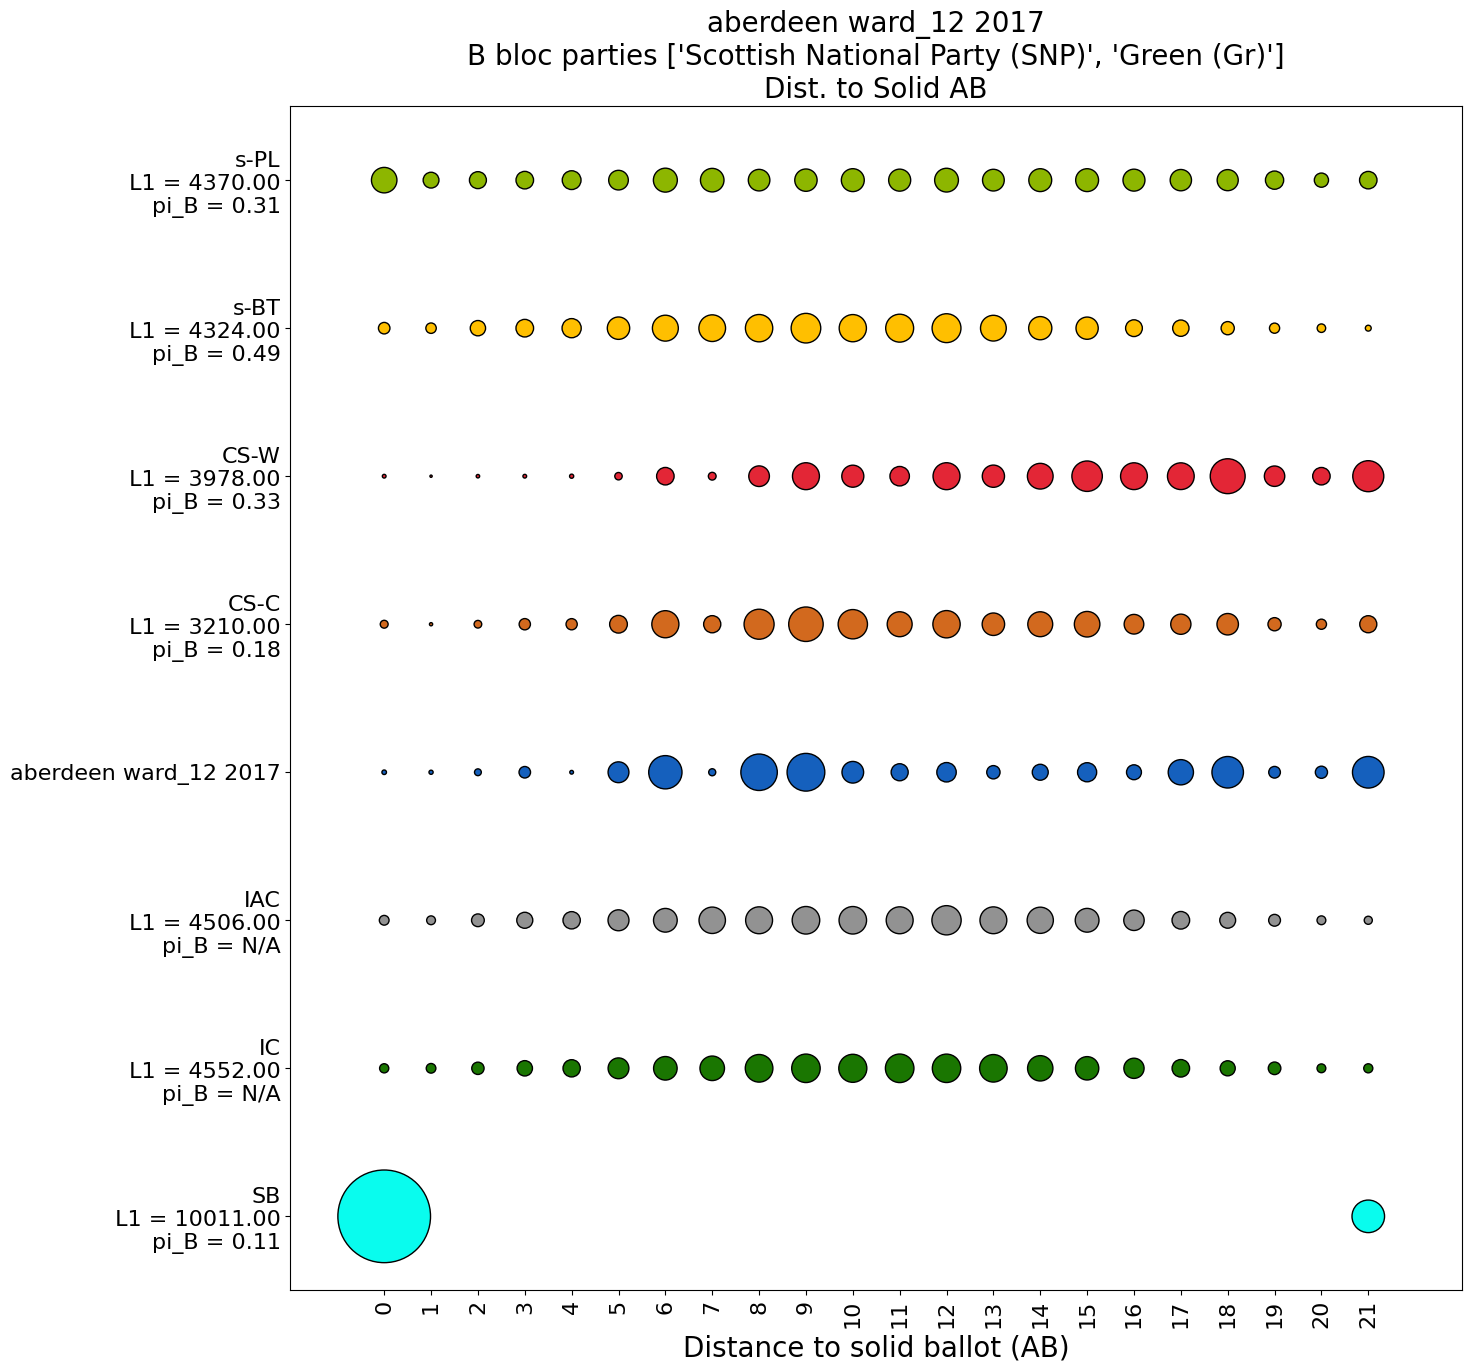

('aberdeen', 2022, 12)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

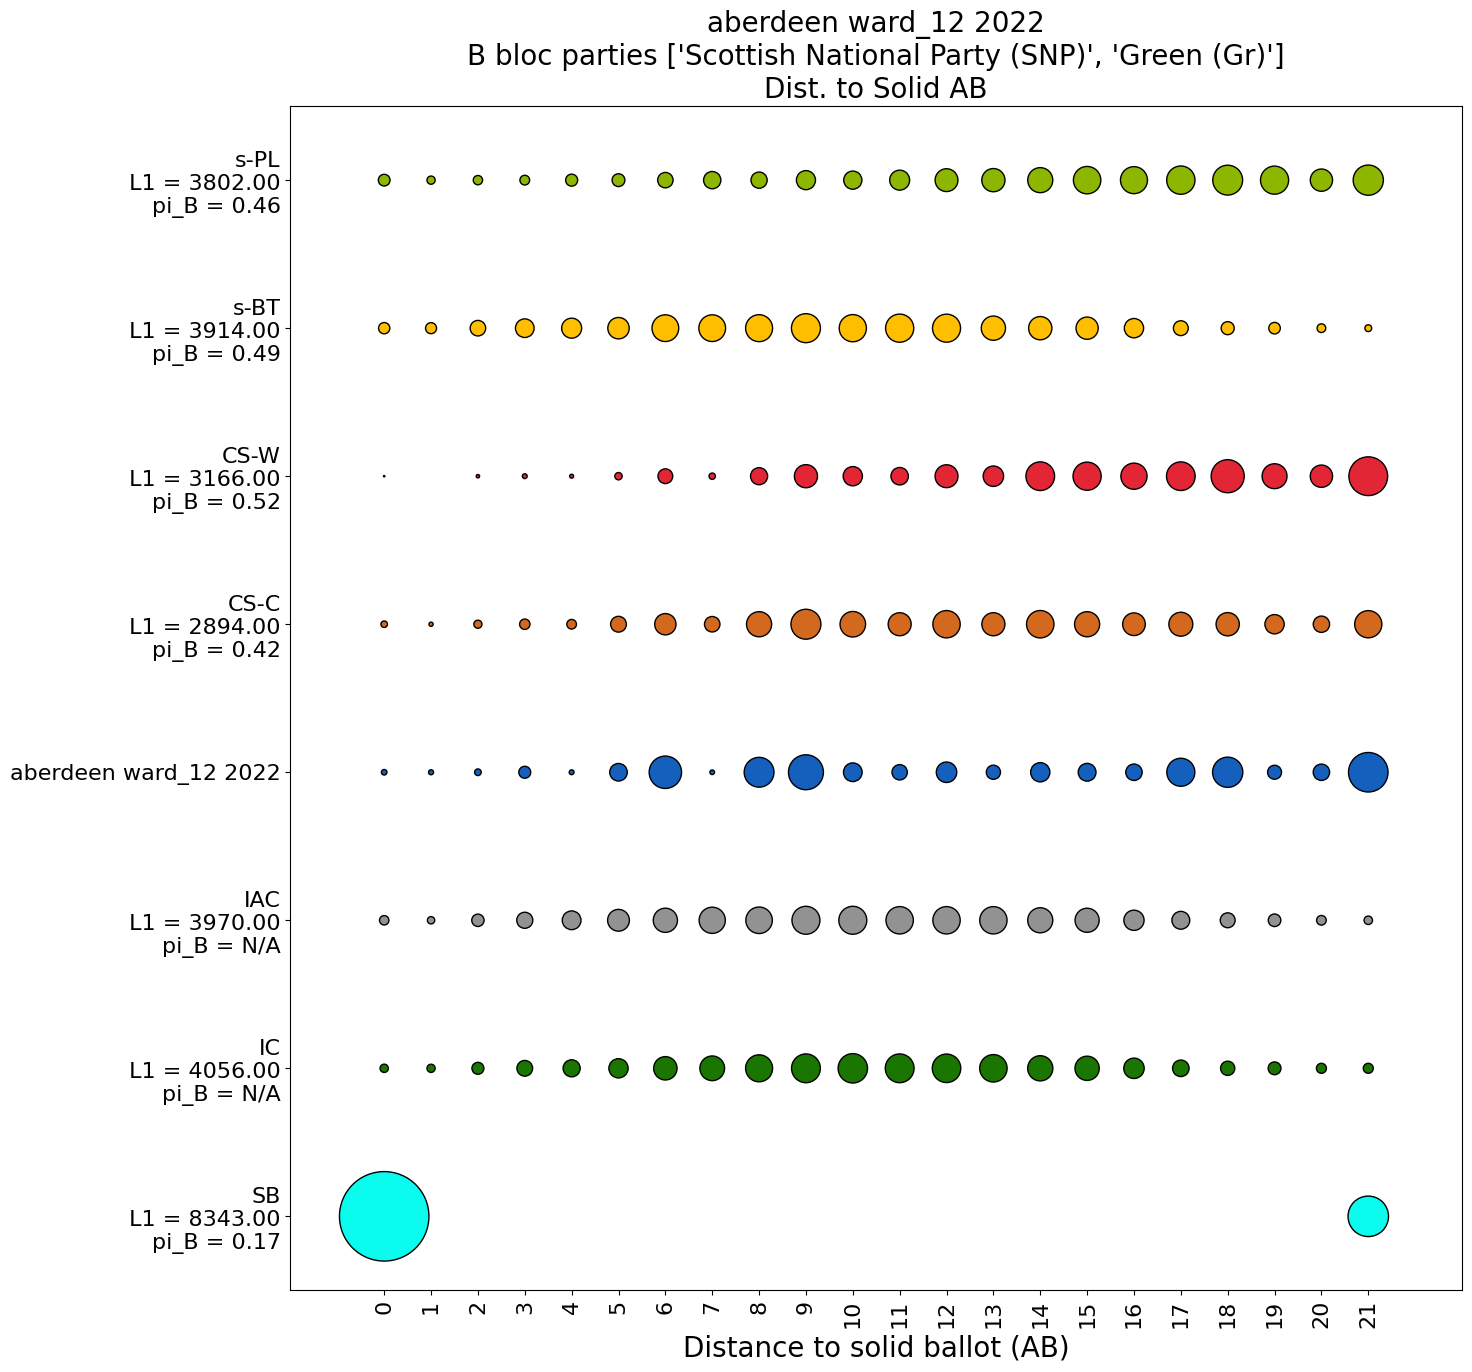

('angus', 2012, 8)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

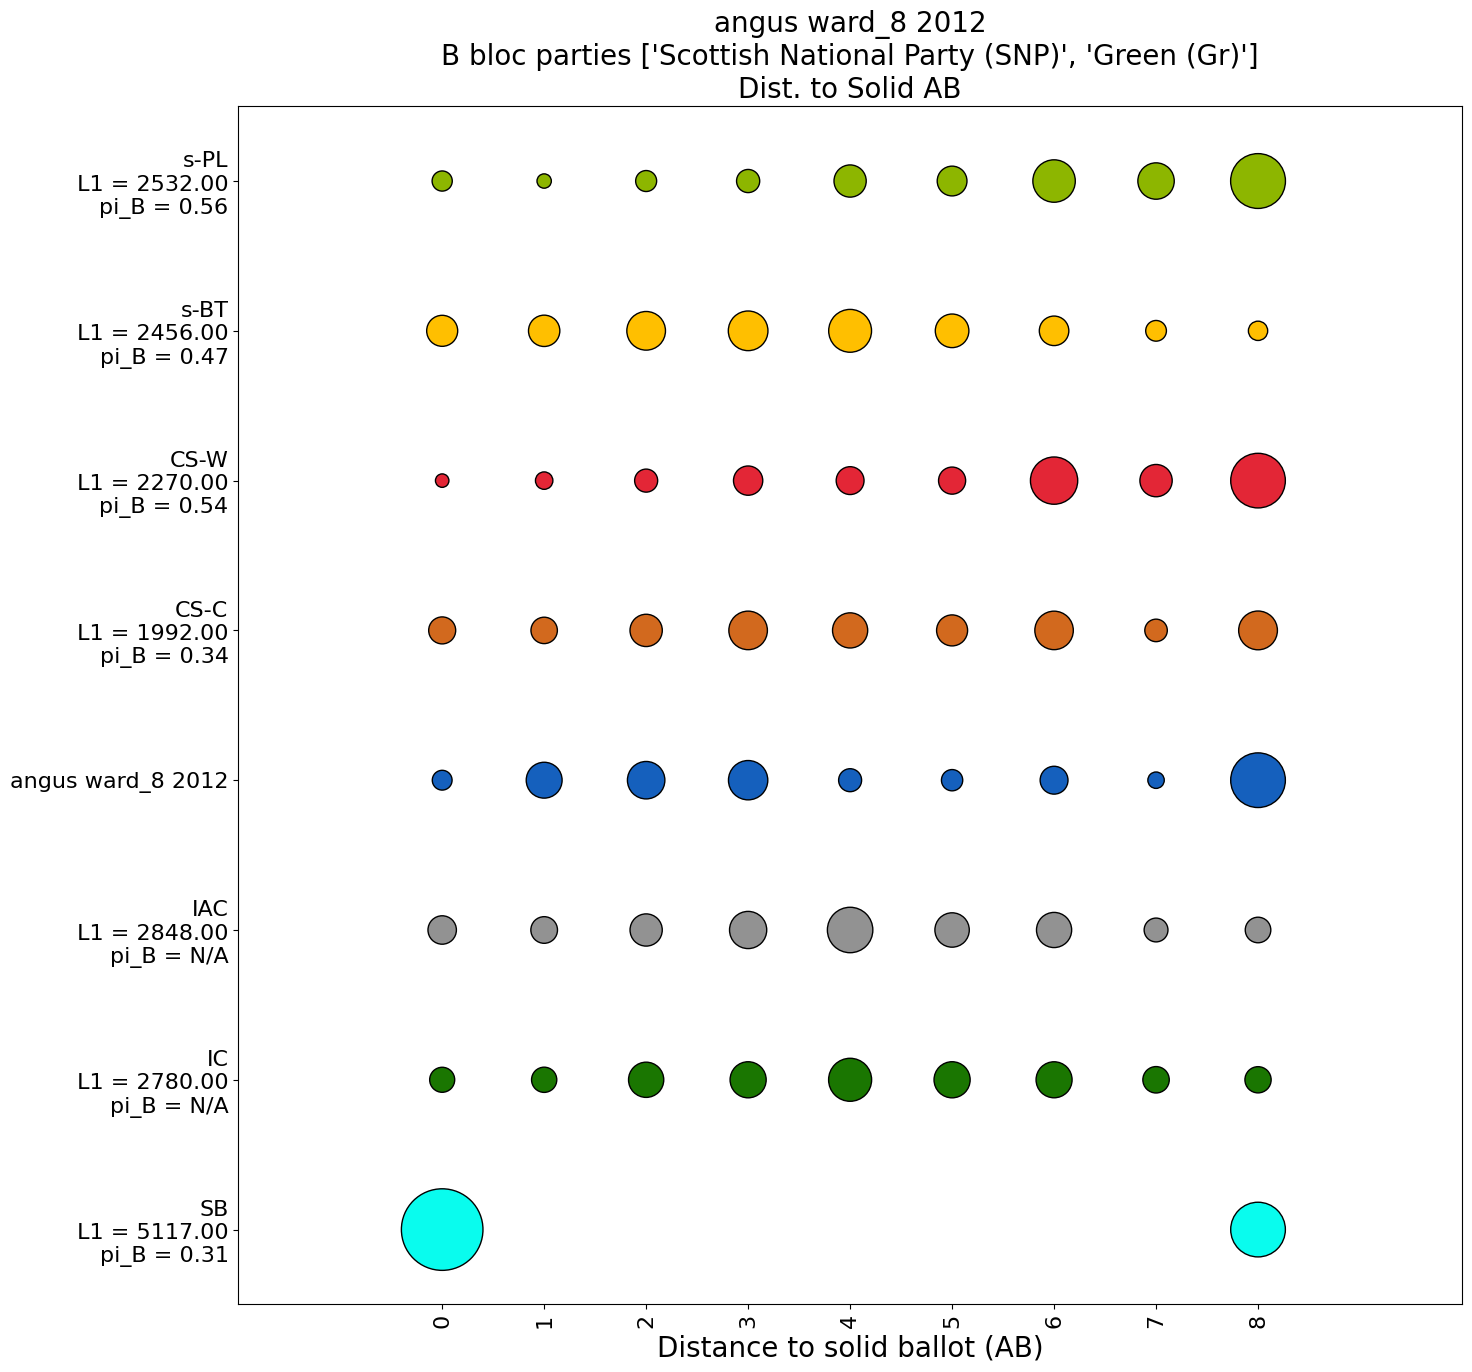

('falkirk', 2017, 6)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

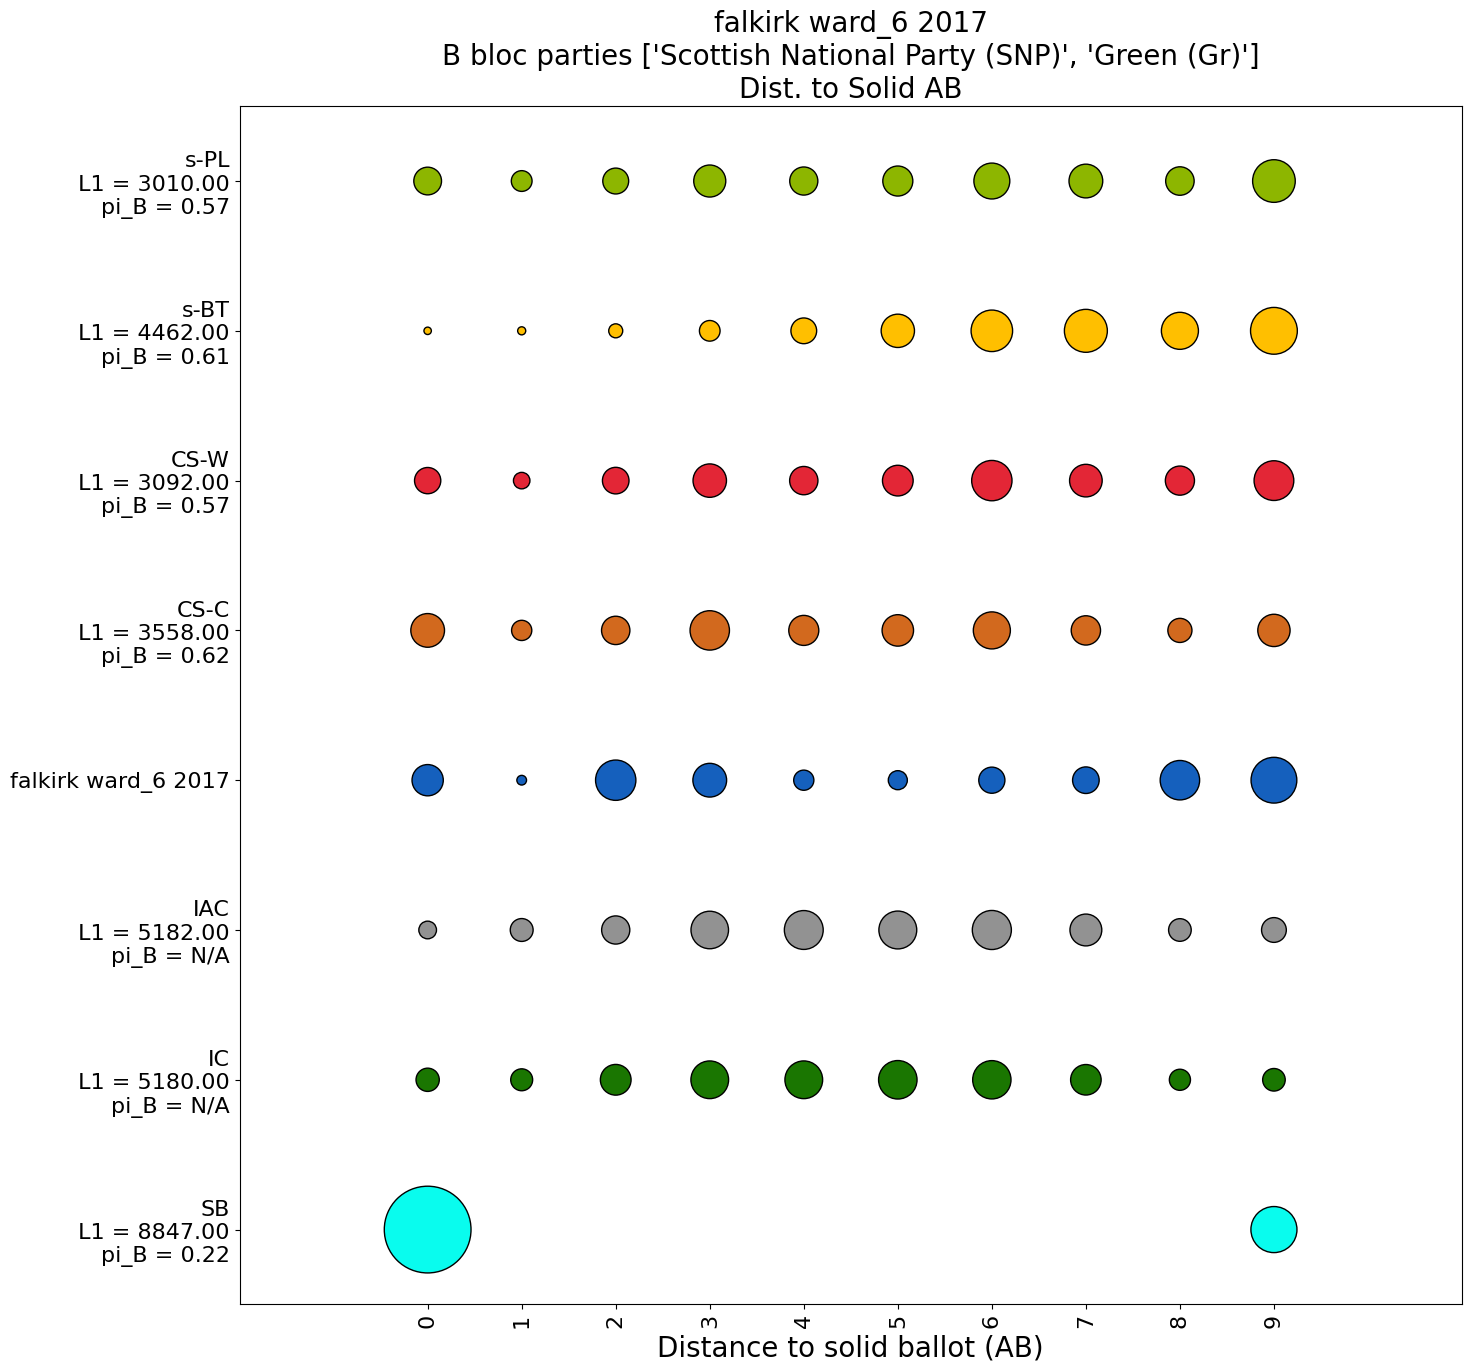

('clackmannanshire', 2012, 2)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

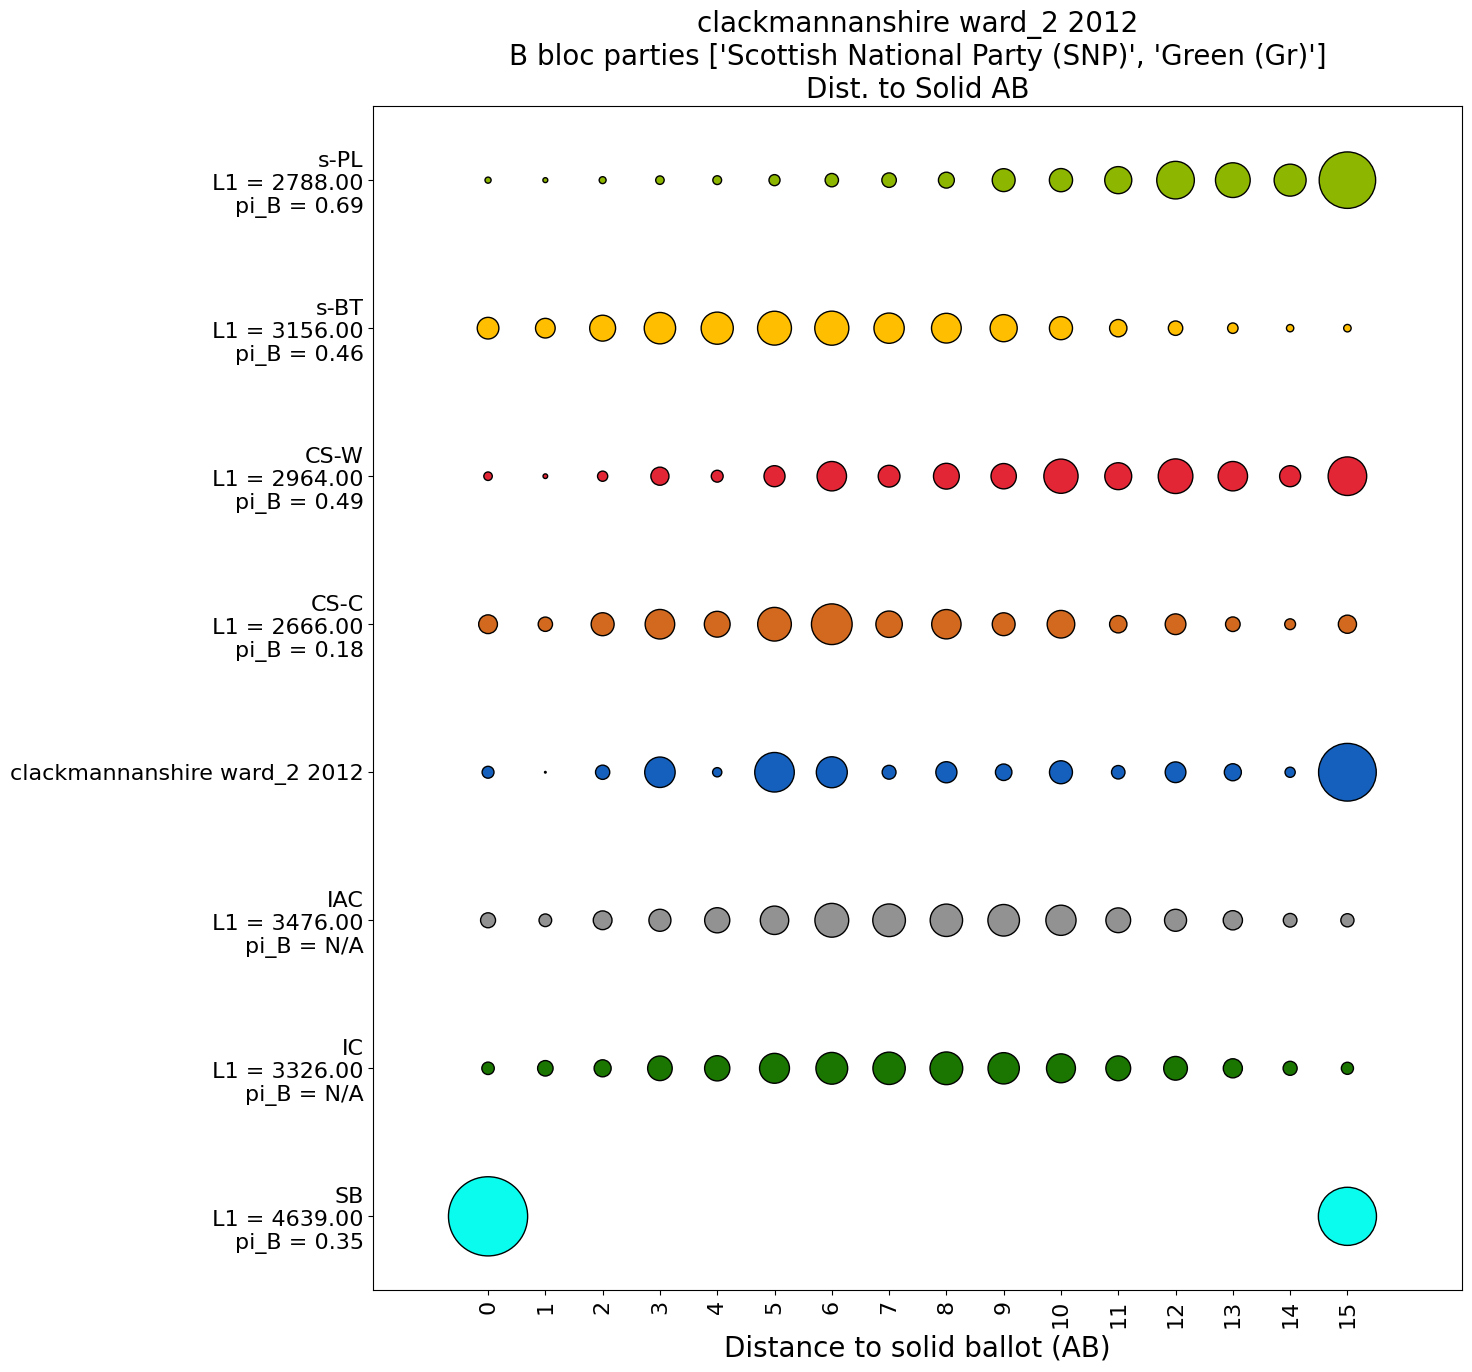

('renfrewshire', 2017, 1)
SB
IC
IAC
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

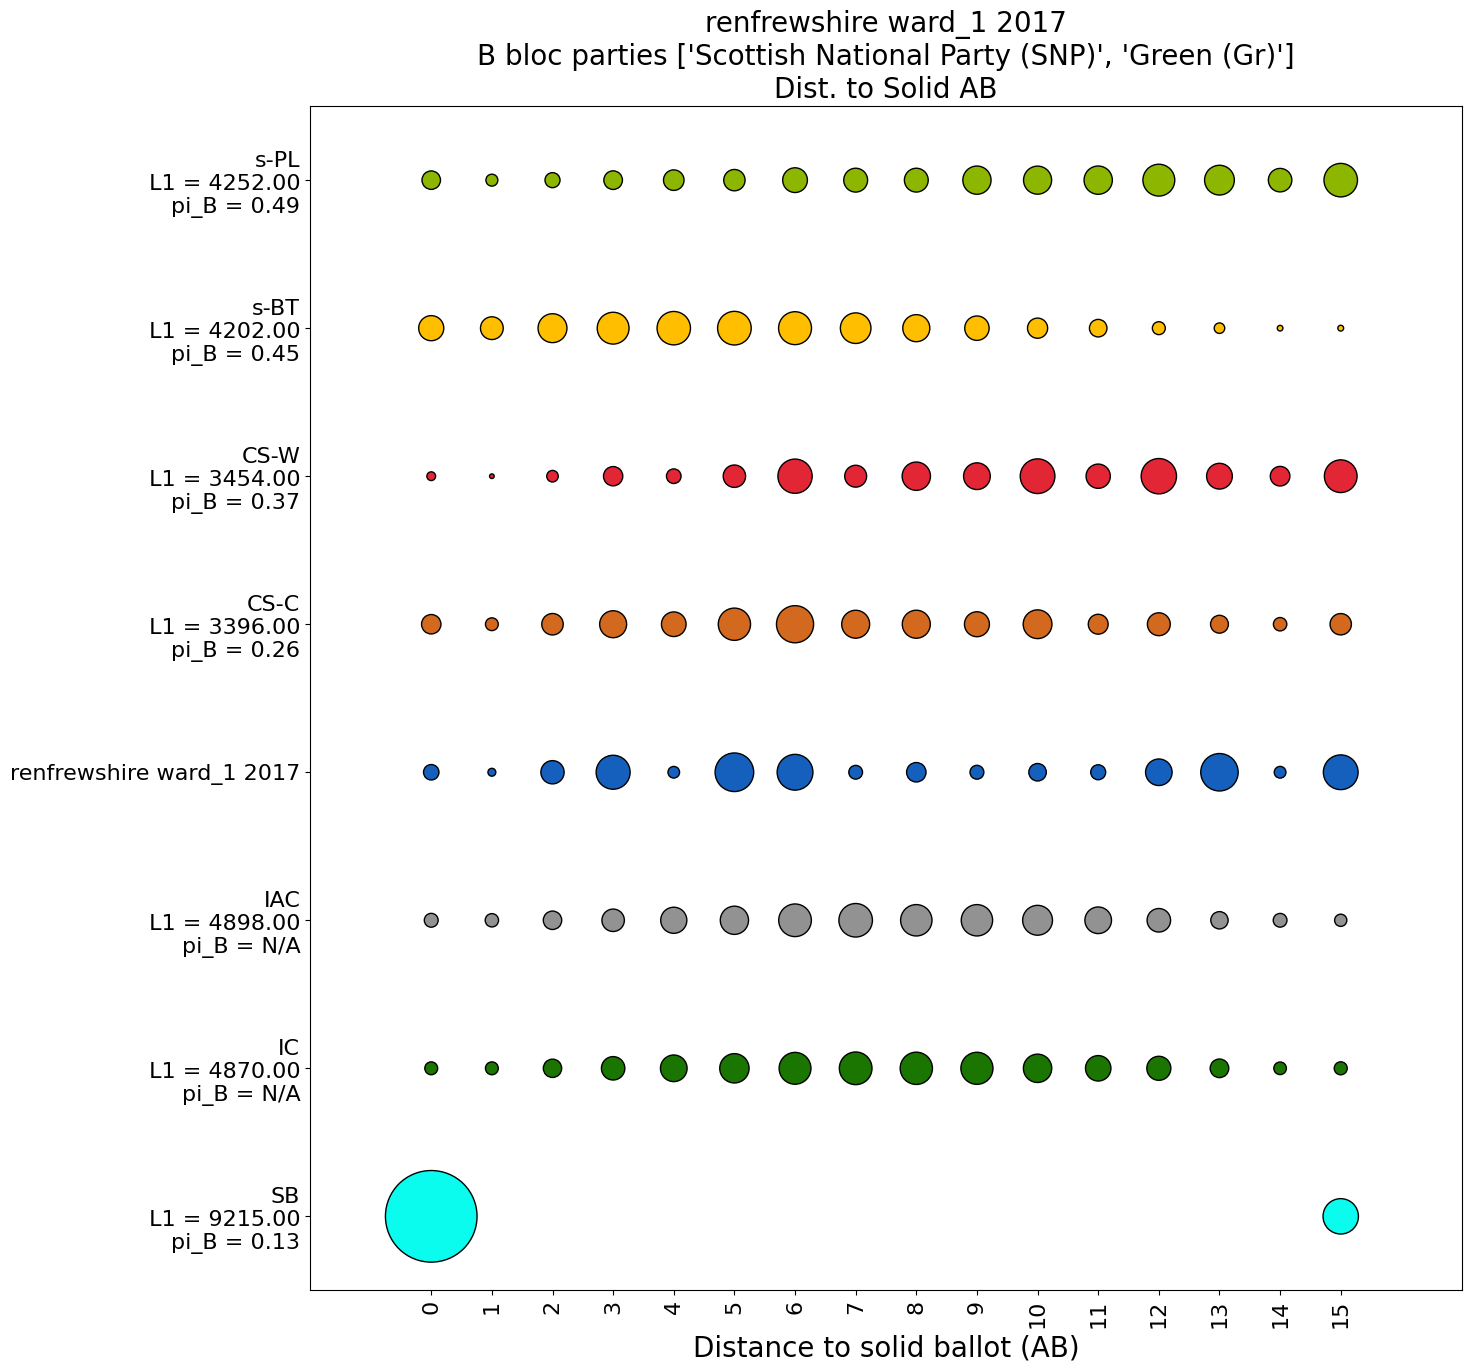

('glasgow', 2012, 16)
SB
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

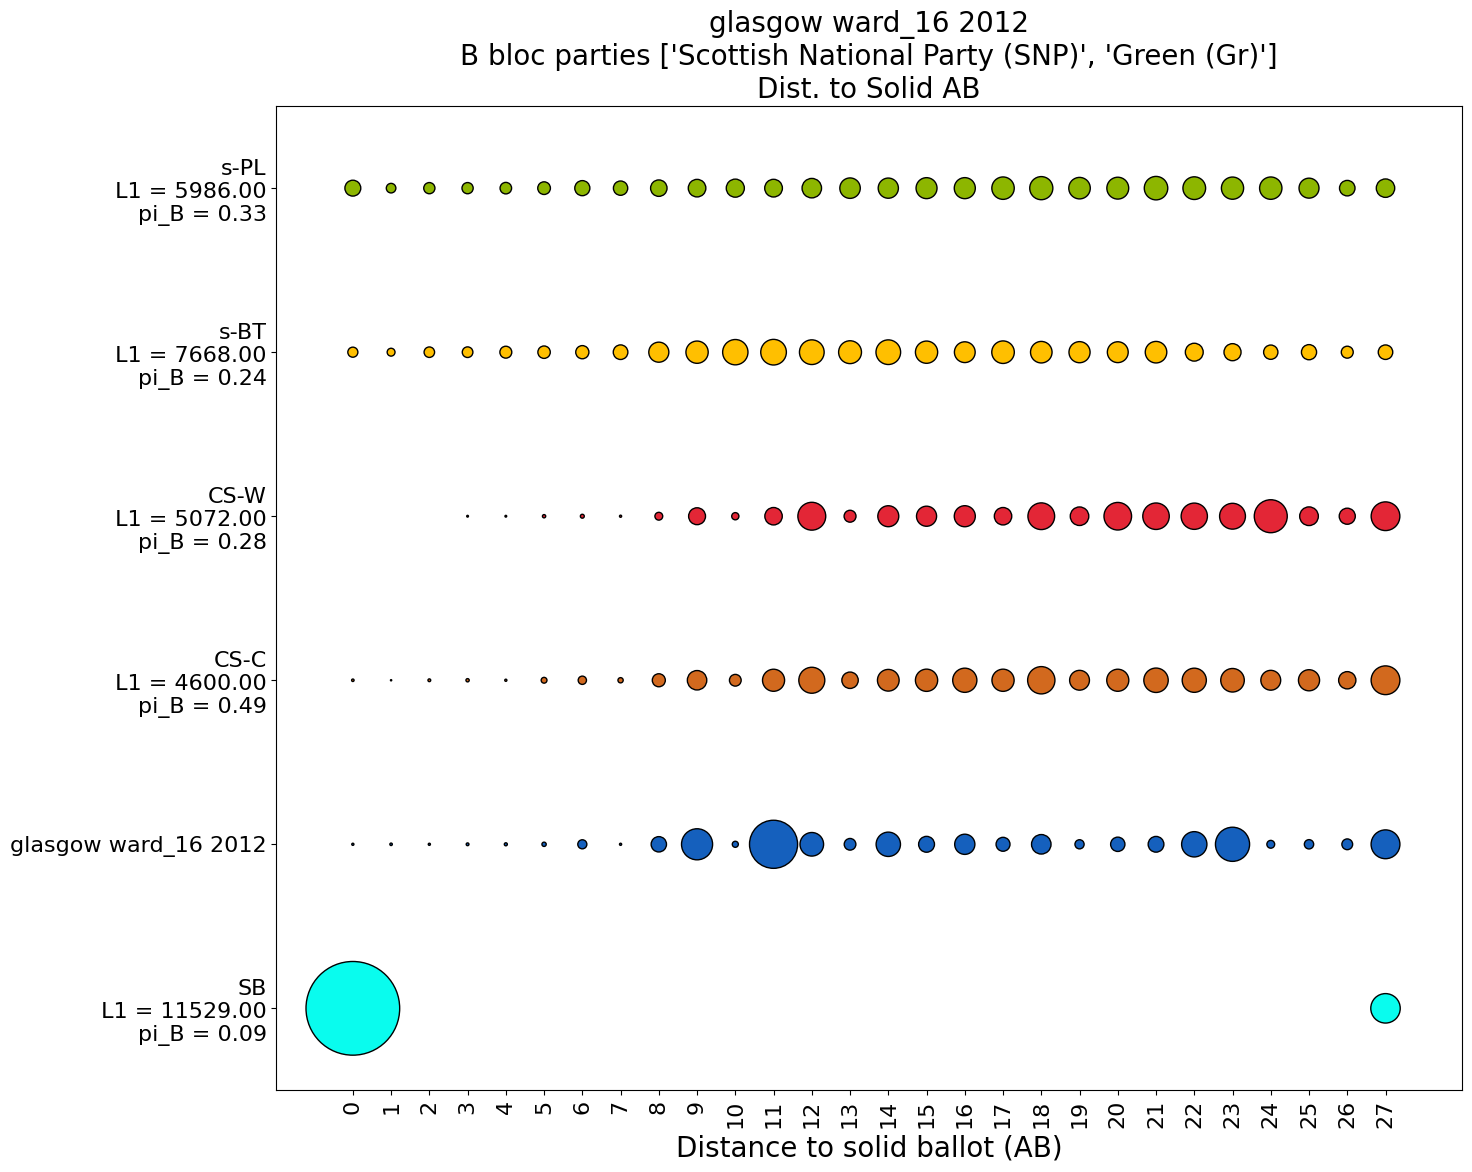

('north-ayrshire', 2022, 1)
SB
CS-C
CS-W
s-BT
s-PL


<Figure size 640x480 with 0 Axes>

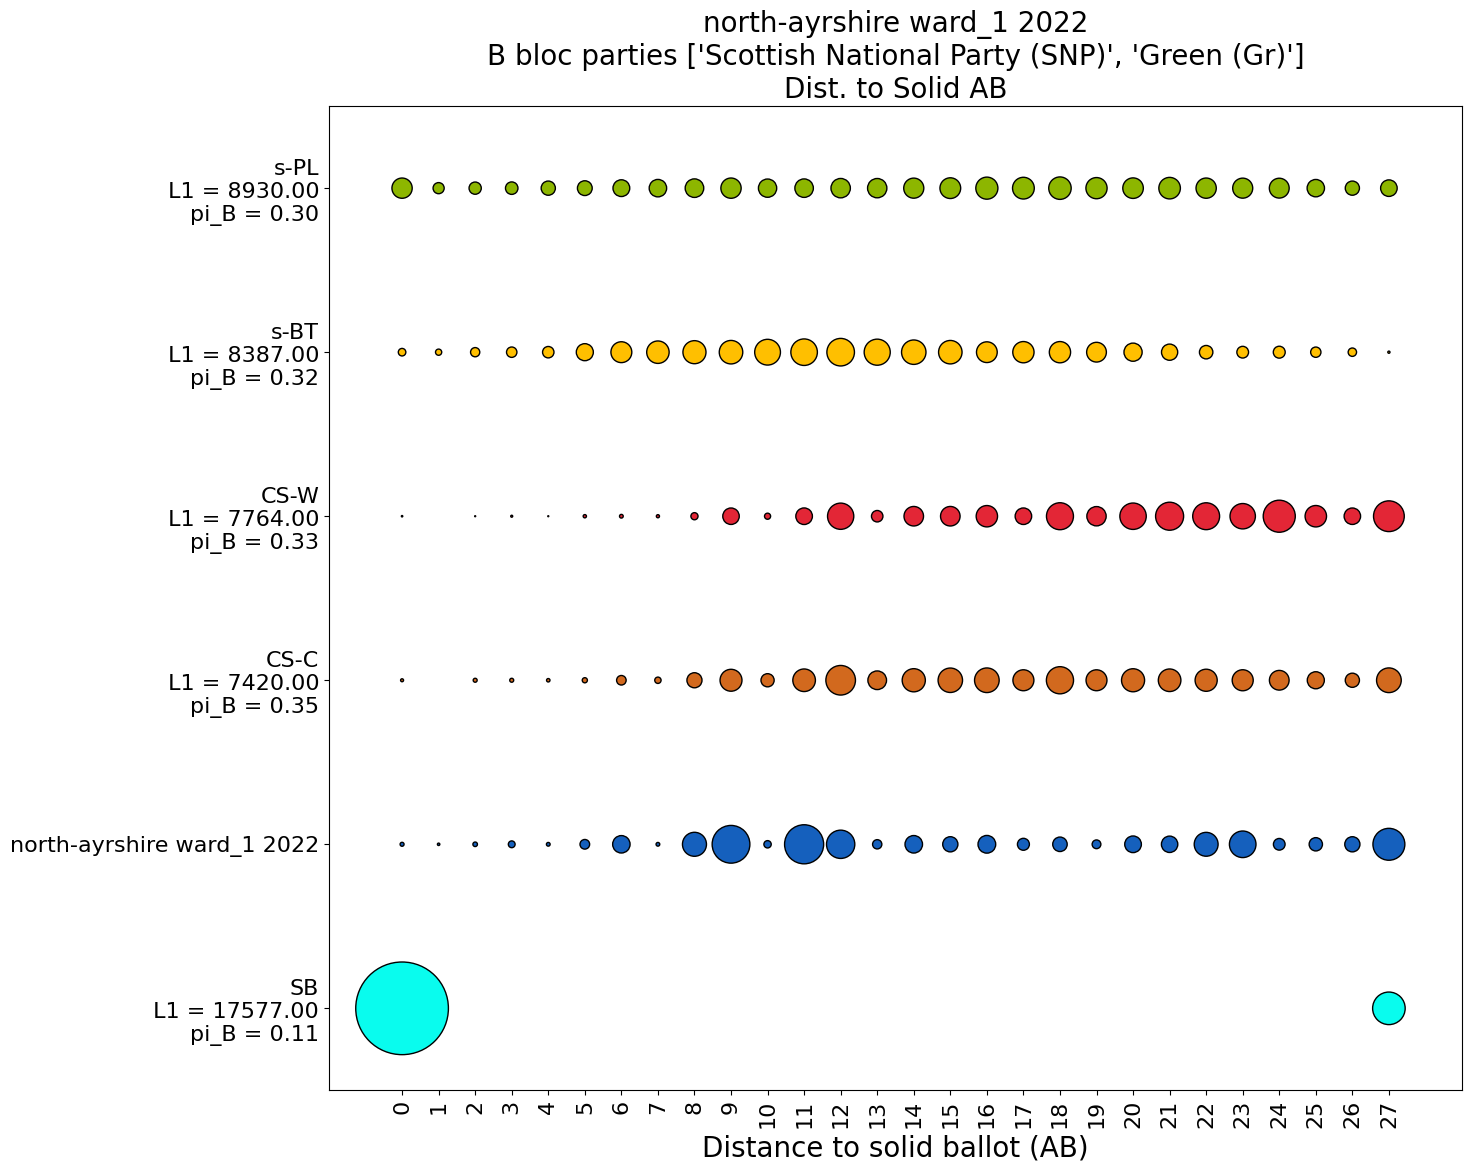

<Figure size 640x480 with 0 Axes>

In [5]:
bloc_order = "AB"
metric = "distance"

for key, file_name in file_names.items():
    print(key)
    city, year, ward = key
    election = " ".join([str(x) for x in key] )

    # too many cands for IC, IAC
    if city in ["glasgow", "north-ayrshire"]:
        temp_old_models = ["SB"]
        height = 12
    else: 
        temp_old_models = ["SB", "IC", "IAC"]
        # temp_old_models = ["IC", "IAC"]

        height = 14

    fig, ax = plt.subplots(figsize = (15, height))
    
    ward_label = f"{city} ward_{ward} {year}"

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    # scot_diss = diss_profile_to_solid(scottish_profile, cand_to_bloc, bloc_to_cand_num, bloc_order)
    # scot_dist = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)

    # if metric == "distance":
    #     scot_data = scot_dist
    # elif metric == "dissim":
    #     scot_data = scot_diss


    old_opt_data = []
    new_opt_data = []
    opt_l1s = {}
    opt_cohesion = {}

    
    model_list = temp_old_models+new_models
    for model in model_list:
        print(model)
        # min pi b, min l1, distances_model, distances_scottish
        with open(f"EC_paper/scottish/l1/data/1_bloc/{ward_label}_one_bloc_optimized_l1_{model}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
            min_pi_b, min_l1, distances, scot_data = pickle.load(f)

        min_l1 = float(min_l1)
        if model in temp_old_models:
            if metric == "distance":
                old_opt_data.append(distances)
            elif metric == "dissim":
                old_opt_data.append(dissims)
                
        else:
            if metric == "distance":
                new_opt_data.append(distances)
            elif metric == "dissim":
                new_opt_data.append(dissims)

        opt_l1s[model] = round(min_l1,2)
        opt_cohesion[model] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

    title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"

    colors = [model_to_color[m] for m in temp_old_models]+[scottish_color]+[model_to_color[m] for m in new_models]
    pi_b_tex = "pi_B" #r"$\pi_B$"
    l1_tex = "L1" #r"$d_{wass}$"
    
    labels = [f"{m}\n {l1_tex} = {opt_l1s[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in temp_old_models] +[ward_label] + \
        [f"{m}\n {l1_tex} = {opt_l1s[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in new_models]

    bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                            labels, 
                            colors, 
                            title+f"Dist. to Solid {bloc_order}",
                            bloc_order,
                            size = 20000,)
                            

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/bubble_plots/{ward_label}_swap_distance_bubble_plots.pdf")
    plt.clf()
    




# 1 bloc bubble dist

In [ ]:
bloc_order = "AB"
# stat = "WD" # wasserstein distance

for key, file_name in file_names.items():
    city, year, ward = key
    election = " ".join([str(x) for x in key] )

    # too many cands for IC, IAC
    if city in ["glasgow", "north-ayrshire"]:
        # temp_old_models = ["SB"]
        temp_old_models = []
        height = 8
    else: 
        # temp_old_models = ["SB", "IC", "IAC"]
        temp_old_models = ["IC", "IAC"]

        height = 10

    fig, ax = plt.subplots(figsize = (15, height))
    
    ward_label = f"{city} ward_{ward} {year}"

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)
  


    old_opt_data = []
    new_opt_data = []
    opt_wds = {}
    opt_cohesion = {}

    
    model_list = temp_old_models+new_models
    for model_str in model_list:
        # with open(f"/cluster/tufts/mggg/cdonna01/EC_paper/scottish/draft_2/diss_data/1_bloc/diss_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
        #     min_pi_b, opt_distances = pickle.load(f)

        data = []
        with open(f"/cluster/tufts/mggg/cdonna01/EC_paper/scottish/draft_2/model_fitting/dist/dist_to_solid_{election}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.csv", newline='') as csvfile:
            csvreader = csv.reader(csvfile)

            for row in csvreader:
                data.append(row)



        if model_str in temp_old_models:
            old_opt_data.append([float(x) for x in data[1]])
        else:
            new_opt_data.append([float(x) for x in data[1]])
        opt_wds[model_str] = round(float(data[0][1]),2)
        # opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

    title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"

    colors = [model_to_color[m] for m in temp_old_models]+[scottish_color]+[model_to_color[m] for m in new_models]
    # pi_b_tex = "pi_B" #r"$\pi_B$"
    d_wass_tex = "d_wass" #r"$d_{wass}$"
    

    # labels = [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in temp_old_models] +[ward_label] + \
    #     [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in new_models]
    labels = [f"{m}\n {d_wass_tex} = {opt_wds[m]}" for m in temp_old_models] +[ward_label] + \
        [f"{m}\n {d_wass_tex} = {opt_wds[m]}" for m in new_models]

    bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                            labels, 
                            colors, 
                            title+f"Distance to Solid {bloc_order}",
                            bloc_order,
                            size = 20000,)
                            

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/bubble_plots/{ward_label}_swap_distance_bubble_plots.pdf")
    plt.clf()
    



# scot hist

In [ ]:
for key, file_name in file_names.items():
    city, year, ward = key
    label = f"{city.capitalize()} Ward {ward} {year}"
    print(label)
    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    
    dist_to_solid = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_to_cand_num)

    fig,ax = plt.subplots(figsize=(8,6))
    bin_min = 0
    bin_max = max(dist_to_solid)
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    ax.hist(dist_to_solid, bins = bins, label = label , density= True, alpha = 1, color = scottish_color)
    ax.set_xticks(range(int(bin_max)+1))
    ax.tick_params(axis='x', labelrotation=90)
    # ax.legend()
    ax.set_xlabel("Distance to solid (A over B)")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}")

    # plt.show()
    plt.tight_layout()
    plt.savefig(f"figures/{label}_distance_to_solid_hist.pdf")
    plt.clf()
    



# Highlighted elections

In [ ]:
#aberdeen 12 2017 both cs
bloc_order = "AB"
stat = "WD"

key = ("aberdeen", 2017, 12)
file_name = file_names[key]
fig, ax = plt.subplots(figsize = (10, 8))
city, year, ward = key
ward_label = f"{city} ward_{ward} {year}"
print(ward_label)

scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}

# count the number of candidates in each bloc
bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)
data = {}

# draft_2/distance_data/1_bloc/distance_to_solid_renfrewshire ward_1 2017_one_bloc_optimized_WD_solid_bloc_order_AB_b_bloc_parties_['Scottish National Party (SNP)', 'Green (Gr)'].pickle
with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_solid_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
    min_solid_pi_b, solid_data = pickle.load(f)
solid_wass = wasserstein_distance(solid_data, scot_data)

old_opt_data = []
new_opt_data = []
opt_wds = {}
opt_cohesion = {}

models = ["CS-C", "CS-W"]
for model_str in old_models + models:
    with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
        min_pi_b, opt_distances = pickle.load(f)
    
    if model_str in old_models:
        old_opt_data.append(opt_distances)
    else:
        new_opt_data.append(opt_distances)
    opt_wds[model_str] = wasserstein_distance(scot_data, opt_distances)
    opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"
# print([x[0] for x in sorted(opt_wds.items(), key= lambda x: x[1])])
colors = [model_to_color[m] for m in old_models]+[scottish_color]+[model_to_color[m] for m in models]
pi_b_tex = r"$\pi_B$"
d_wass_tex = r"$d_{wass}$"



labels =  [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in old_models]+[ward_label] + \
    [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in models]
bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                        labels, 
                        colors, 
                        title+f"Optimized Cohesion 1 Bloc for {d_wass_tex}",
                        bloc_order,
                        size = 20000,)
                        



plt.tight_layout()
plt.show()
# plt.savefig(f"figures/HIGHLIGHT_{ward_label}_swap_distance_bubble_plots.pdf")
plt.clf()





In [ ]:
# falkrirk 6 2017 both slate, solid
bloc_order = "AB"
stat = "WD"

key = ("falkirk", 2017, 6)
file_name = file_names[key]
fig, ax = plt.subplots(figsize = (10, 6))
city, year, ward = key
ward_label = f"{city} ward_{ward} {year}"
print(ward_label)

scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}

# count the number of candidates in each bloc
bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

scot_data = dist_profile_to_solid(scottish_profile, cand_to_bloc, bloc_order)
data = {}

# draft_2/distance_data/1_bloc/distance_to_solid_renfrewshire ward_1 2017_one_bloc_optimized_WD_solid_bloc_order_AB_b_bloc_parties_['Scottish National Party (SNP)', 'Green (Gr)'].pickle
with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_solid_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
    min_solid_pi_b, solid_data = pickle.load(f)
solid_wass = wasserstein_distance(solid_data, scot_data)

old_opt_data = []
new_opt_data = []
opt_wds = {}
opt_cohesion = {}

models = ["s-PL", "s-BT"]
for model_str in old_models + models:
    with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
        min_pi_b, opt_distances = pickle.load(f)
    
    if model_str in old_models:
        old_opt_data.append(opt_distances)
    else:
        new_opt_data.append(opt_distances)
    opt_wds[model_str] = wasserstein_distance(scot_data, opt_distances)
    opt_cohesion[model_str] = round(min_pi_b,2) if isinstance(min_pi_b, float) else min_pi_b

title = f"{ward_label}\nB bloc parties {b_bloc_parties}\n"
# print([x[0] for x in sorted(opt_wds.items(), key= lambda x: x[1])])
colors = [model_to_color[m] for m in old_models]+[scottish_color]+[model_to_color[m] for m in models]
pi_b_tex = r"$\pi_B$"
d_wass_tex = r"$d_{wass}$"



labels =  [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]}" for m in old_models]+[ward_label] + \
    [f"{m}\n {d_wass_tex} = {opt_wds[m]:.2f}\n{pi_b_tex} = {opt_cohesion[m]:.2f}" for m in models]
bubble_plot_integer(ax, old_opt_data+[scot_data] + new_opt_data, 
                        labels, 
                        colors, 
                        title+f"Optimized Cohesion 1 Bloc for {d_wass_tex}",
                        bloc_order,
                        size = 20000,)
                        



plt.tight_layout()
plt.show()
# plt.savefig(f"figures/HIGHLIGHT_{ward_label}_swap_distance_bubble_plots.pdf")
plt.clf()





Table 1: stv prop

In [ ]:
bloc_order = "AB"
stat = "WD"
# to do, make 1 row 3 column area plots
# each row is FPV, borda, opt
# each col is model type
for key, file_name in file_names.items():
    city, year, ward = key
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    m_parameters = estimate_1_bloc_parameters(file_name, b_bloc_parties)

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    
    # print(bloc_to_cand_num)
    print("FPV", round(m_parameters["bloc_first"]["B"],2), round(m_parameters["bloc_first"]["B"],2)*num_seats)
    print("BORDA", round(m_parameters["borda_share"]["B"],2), round(m_parameters["borda_share"]["B"],2)*num_seats)
    # record number of B winners
    election  = STV(profile = scottish_profile, transfer=fractional_transfer, seats = num_seats)
    results = election.run_election()
    winners= [c for s in results.winners() for c in s]
    print(winners)
    print([cand_to_party[c] for c in winners])
    num_B_winners = len([c for c in winners if cand_to_bloc[c] == "B"])

    print("Seats won by B bloc", num_B_winners)
    print()
    print("\n-----------\n")
    


